In [ ]:
import pandas as pd
from pathlib import Path

In [ ]:
RAW = Path("../data/raw")       
PROCESSED = Path("../data/processed")

clinical = pd.read_csv(RAW / "hgsoc_tcga_gdc_clinical_data.tsv", sep="\t")
imaging = pd.read_excel(RAW / "tcga_ov_imaging_metadata.xlsx")

In [5]:
clinical_cleaned = (
    clinical
    .rename(columns=lambda x: x.strip()                 
                             .lower()                 
                             .replace(' ', '_')       
                             .replace('-', '_'))  
    .drop_duplicates()  
)

clinical_cleaned.head()


,study_id,patient_id,sample_id,diagnosis_age,biopsy_site,cancer_type,cancer_type_detailed,last_communication_contact_from_initial_pathologic_diagnosis_date,birth_from_initial_pathologic_diagnosis_date,death_from_initial_pathologic_diagnosis_date,...,project_name,project_state,race_category,number_of_samples_per_patient,sample_type,sample_type_id,sex,tmb_(nonsynonymous),patient's_vital_status,year_of_diagnosis
0,hgsoc_tcga_gdc,TCGA-04-1331,TCGA-04-1331-01,78.0,Ovary,High-Grade Serous Ovarian Cancer,High-Grade Serous Ovarian Cancer,1224.0,-28848.0,1336.0,...,High-Grade Serous Ovarian Cancer,released,WHITE,1,Primary Tumor,1,Female,3.533333,Dead,2004.0
1,hgsoc_tcga_gdc,TCGA-04-1332,TCGA-04-1332-01,70.0,Ovary,High-Grade Serous Ovarian Cancer,High-Grade Serous Ovarian Cancer,1247.0,-25786.0,1247.0,...,High-Grade Serous Ovarian Cancer,released,WHITE,1,Primary Tumor,1,Female,1.533333,Dead,2002.0
2,hgsoc_tcga_gdc,TCGA-04-1335,TCGA-04-1335-01,60.0,Ovary,High-Grade Serous Ovarian Cancer,High-Grade Serous Ovarian Cancer,NaN,-21963.0,55.0,...,High-Grade Serous Ovarian Cancer,released,BLACK OR AFRICAN AMERICAN,1,Primary Tumor,1,Female,NaN,Dead,2005.0
3,hgsoc_tcga_gdc,TCGA-04-1336,TCGA-04-1336-01,55.0,Ovary,High-Grade Serous Ovarian Cancer,High-Grade Serous Ovarian Cancer,1495.0,-20271.0,NaN,...,High-Grade Serous Ovarian Cancer,released,WHITE,1,Primary Tumor,1,Female,3.766667,Alive,2005.0
4,hgsoc_tcga_gdc,TCGA-04-1337,TCGA-04-1337-01,78.0,Ovary,High-Grade Serous Ovarian Cancer,High-Grade Serous Ovarian Cancer,NaN,-28626.0,61.0,...,High-Grade Serous Ovarian Cancer,released,WHITE,1,Primary Tumor,1,Female,NaN,Dead,2005.0


In [6]:
imaging_cleaned = (
    imaging
    .rename(columns=lambda x: x.strip().lower().replace(" ", "_"))  
    .drop_duplicates()  
)
imaging_cleaned.head(2)

,patient_id,patient_name,patient_birth_date,patient_sex,ethnic_group,phantom,species_code,species_description,study_instance_uid,study_date,...,manufacturer_model_name,software_versions,image_count,max_submission_timestamp,license_name,license_uri,collection_uri,file_size,date_released,third_party_analysis
0,TCGA-24-0966,TCGA-24-0966,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.7777.4007.330693106714...,1992-05-01 00:00:00.0,...,Sensation 64,syngo CT 2007S,2,2013-08-28 23:24:07.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.NDO1MDFQ,1054346,2013-08-28 23:24:07.0,NaN
1,TCGA-24-0966,TCGA-24-0966,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.7777.4007.330693106714...,1992-05-01 00:00:00.0,...,Sensation 64,syngo CT 2007S,114,2013-08-28 23:24:45.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.NDO1MDFQ,60104818,2013-08-28 23:24:45.0,NaN


In [7]:
imaging_cleaned.to_csv("../data/processed/tcga_ov_imaging_cleaned.csv", index=False)

In [8]:
clinical_cleaned.to_csv("../data/processed/hgsoc_tcga_gdc_clinical_cleaned.csv", index=False)

In [9]:
def data_audit(df, name="Dataset"):
    print(f"===== {name} Audit =====")
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")
    
    if "patient_id" in df.columns:
        print(f"Unique patients: {df['patient_id'].nunique()}")
    
    missing = df.isna().mean() * 100
    print("\n% Missing per column:")
    print(missing.sort_values(ascending=False))
    

In [10]:
hgsoc_tcga_gdc_clinical_cleaned = pd.read_csv("../data/processed/hgsoc_tcga_gdc_clinical_cleaned.csv")
tcga_ov_imaging_cleaned = pd.read_csv("../data/processed/tcga_ov_imaging_cleaned.csv")

In [11]:
data_audit(hgsoc_tcga_gdc_clinical_cleaned, "Clinical")

===== Clinical Audit =====
Number of rows: 604
Number of columns: 40
Unique patients: 588

% Missing per column:
prior_malignancy                                                     98.675497
disease_free_status                                                  53.311258
disease_free_(months)                                                53.311258
ethnicity_category                                                   41.887417
death_from_initial_pathologic_diagnosis_date                         41.225166
mutation_count                                                       32.947020
tmb_(nonsynonymous)                                                  32.947020
last_communication_contact_from_initial_pathologic_diagnosis_date    13.410596
race_category                                                         6.788079
birth_from_initial_pathologic_diagnosis_date                          3.642384
diagnosis_age                                                         3.642384
figo_stage        

In [44]:
data_audit(tcga_ov_imaging_cleaned, "Imaging")

===== Imaging Audit =====
Number of rows: 844
Number of columns: 36
Unique patients: 143

% Missing per column:
patient_birth_date                         100.000000
study_id                                   100.000000
longitudinal_temporal_offset_from_event    100.000000
longitudinal_temporal_event_type           100.000000
third_party_analysis                       100.000000
annotations_flag                           100.000000
ethnic_group                                98.222749
admitting_diagnosis_description             97.156398
protocol_name                               11.966825
software_versions                            2.488152
series_description                           2.369668
patient_age                                  0.829384
series_date                                  0.829384
manufacturer                                 0.355450
manufacturer_model_name                      0.355450
study_description                            0.236967
series_number           

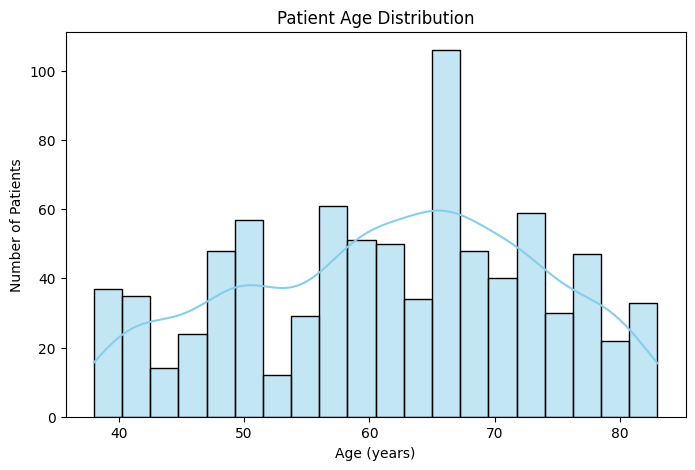

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(tcga_ov_imaging_cleaned['patient_age_numeric'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Patient Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.show()